<a href="https://colab.research.google.com/github/Sahilya31/Syntecxhub-Task-1/blob/main/Task-3_HR_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dropdown(description='Dept Slicer:', index=5, options=('All Departments', 'Engineering', 'Sales', 'HR', 'Marke…

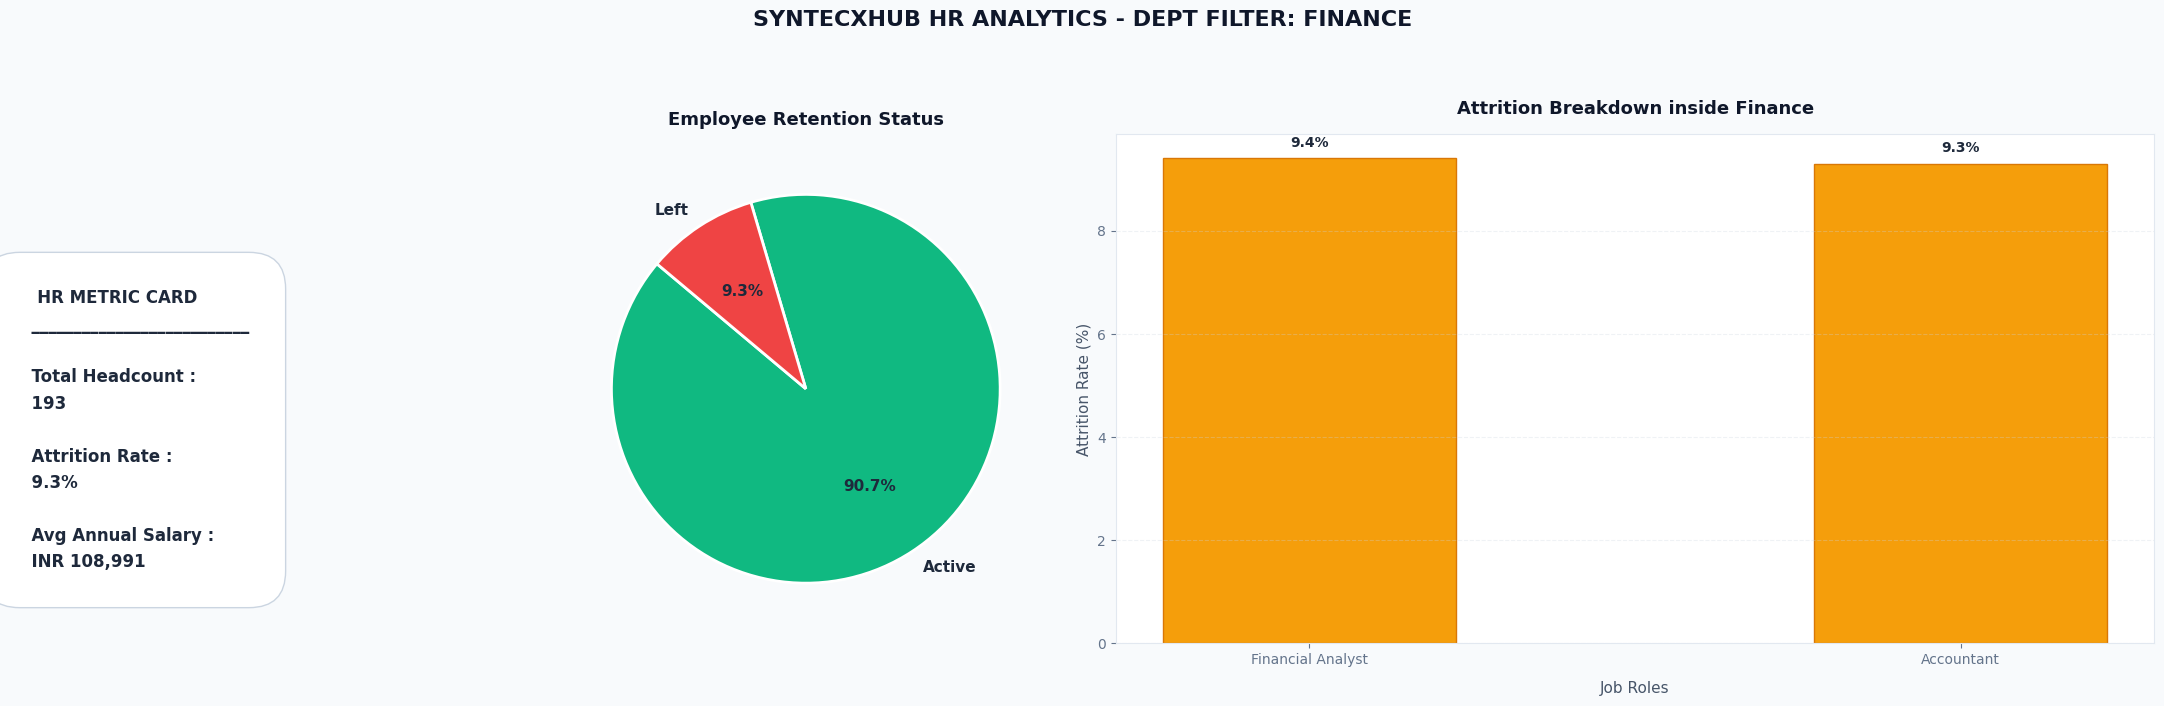

In [2]:
import sqlite3
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. इन-मेमोरी SQLite डेटाबेस सेटअप
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 2. HR Dashboard के लिए एम्प्लॉई टेबल बनाना
cursor.execute('''
CREATE TABLE Employees (
    employee_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT,
    department TEXT,
    role TEXT,
    salary INTEGER,
    experience_years INTEGER,
    performance_score TEXT,
    status TEXT -- 'Active' या 'Left' (Attrition ट्रैक करने के लिए)
);
''')

# 3. डमी डेटा जनरेट करना
departments = ['Engineering', 'Sales', 'HR', 'Marketing', 'Finance']
roles_dict = {
    'Engineering': ['Software Engineer', 'QA Engineer', 'Tech Lead'],
    'Sales': ['Sales Executive', 'Account Manager'],
    'HR': ['HR Specialist', 'Recruiter'],
    'Marketing': ['Digital Marketer', 'SEO Specialist'],
    'Finance': ['Financial Analyst', 'Accountant']
}
perf_scores = ['Excellent', 'Good', 'Average', 'Poor']
names = ['Amit', 'Rahul', 'Priya', 'Sneha', 'Vikram', 'Neha', 'Rohan', 'Anjali', 'Karan', 'Pooja']

employees_batch = []
for i in range(1, 1001): # 1000 एम्प्लॉई का डेटा
    dept = random.choice(departments)
    role = random.choice(roles_dict[dept])
    name = f"{random.choice(names)} {random.randint(100, 999)}"
    exp = random.randint(1, 15)

    # एक्सपीरियंस के हिसाब से सैलरी
    base_salary = random.randint(30000, 60000)
    salary = base_salary + (exp * 8000)

    perf = random.choices(perf_scores, weights=[20, 50, 20, 10], k=1)[0]

    # Attrition स्टेटस (Engineering और Sales में थोड़ा ज़्यादा attrition रख रहे हैं)
    if dept in ['Engineering', 'Sales'] and perf in ['Average', 'Poor']:
        status = random.choices(['Active', 'Left'], weights=[70, 30], k=1)[0]
    else:
        status = random.choices(['Active', 'Left'], weights=[88, 12], k=1)[0]

    employees_batch.append((name, dept, role, salary, exp, perf, status))

cursor.executemany('''
INSERT INTO Employees (name, department, role, salary, experience_years, performance_score, status)
VALUES (?, ?, ?, ?, ?, ?, ?);
''', employees_batch)
conn.commit()
clear_output()

# 4. डैशबोर्ड व्यू फंक्शन
def run_hr_dashboard(selected_dept):
    clear_output(wait=True)
    display(dropdown)

    # फ़िल्टर लॉजिक
    if selected_dept == 'All Departments':
        dept_filter = ""
        dept_filter_where = ""
    else:
        dept_filter = f"WHERE department = '{selected_dept}'"
        dept_filter_where = f"AND department = '{selected_dept}'"

    # KPI 1: Total Employees, Attrition Rate, Avg Salary
    kpi_df = pd.read_sql_query(f"""
        SELECT
            COUNT(*) as total_emp,
            ROUND(SUM(CASE WHEN status = 'Left' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as attrition_rate,
            ROUND(AVG(salary), 0) as avg_sal
        FROM Employees {dept_filter};
    """, conn)

    # Chart 1: Status Distribution (Pie Chart)
    pie_df = pd.read_sql_query(f"""
        SELECT status, COUNT(*) as count FROM Employees
        {dept_filter} GROUP BY status;
    """, conn)

    # Chart 2: Attrition by Performance / Role (Bar Chart)
    if selected_dept == 'All Departments':
        bar_df = pd.read_sql_query("""
            SELECT department as x_label,
                   ROUND(SUM(CASE WHEN status = 'Left' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as attr_rate
            FROM Employees
            GROUP BY department ORDER BY attr_rate DESC;
        """, conn)
        bar_title = "Attrition Rate by Department"
        xaxis_title = "Departments"
    else:
        bar_df = pd.read_sql_query(f"""
            SELECT role as x_label,
                   ROUND(SUM(CASE WHEN status = 'Left' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as attr_rate
            FROM Employees
            WHERE department = '{selected_dept}'
            GROUP BY role ORDER BY attr_rate DESC;
        """, conn)
        bar_title = f"Attrition Breakdown inside {selected_dept}"
        xaxis_title = "Job Roles"

    # matplotlib ग्रिड सेटअप
    fig = plt.figure(figsize=(22, 7), facecolor='#f8fafc')
    fig.suptitle(f"SYNTECXHUB HR ANALYTICS - DEPT FILTER: {selected_dept.upper()}",
                 fontweight='bold', fontsize=16, color='#0f172a', y=1.02)

    ax_kpi = plt.subplot2grid((1, 4), (0, 0), facecolor='#ffffff')
    ax_pie = plt.subplot2grid((1, 4), (0, 1), facecolor='#ffffff')
    ax_bar = plt.subplot2grid((1, 4), (0, 2), colspan=2, facecolor='#ffffff')

    for ax in [ax_kpi, ax_pie, ax_bar]:
        ax.spines['top'].set_color('#e2e8f0')
        ax.spines['right'].set_color('#e2e8f0')
        ax.spines['left'].set_color('#e2e8f0')
        ax.spines['bottom'].set_color('#e2e8f0')
        ax.tick_params(colors='#64748b', labelsize=10)

    # KPI कार्ड रेंडर करना
    ax_kpi.axis('off')
    kpi_card_style = dict(facecolor='#ffffff', edgecolor='#cbd5e1', boxstyle='round,pad=2.2')
    kpi_text = (
        f"   HR METRIC CARD\n"
        f"  {"_"*26}\n\n"
        f"  Total Headcount :\n  {kpi_df['total_emp'][0]:,}\n\n"
        f"  Attrition Rate :\n  {kpi_df['attrition_rate'][0]}%\n\n"
        f"  Avg Annual Salary :\n  INR {kpi_df['avg_sal'][0]:,.0f}"
    )
    ax_kpi.text(0.02, 0.15, kpi_text, fontsize=12, fontweight='bold', color='#1e293b', linespacing=1.6, bbox=kpi_card_style)

    # Pie Chart - Active vs Left
    ax_pie.pie(pie_df['count'], labels=pie_df['status'], autopct='%1.1f%%', startangle=140,
               colors=['#10b981', '#ef4444'], # Active=Green, Left=Red
               textprops={'fontsize': 11, 'color': '#1e293b', 'fontweight': 'bold'},
               wedgeprops={'edgecolor': '#ffffff', 'linewidth': 2})
    ax_pie.set_title("Employee Retention Status", fontsize=13, fontweight='bold', color='#0f172a', pad=15)

    # Bar Chart - Attrition Rate
    bars = ax_bar.bar(bar_df['x_label'], bar_df['attr_rate'], color='#f59e0b', width=0.45, edgecolor='#d97706', linewidth=1)
    ax_bar.set_title(bar_title, fontsize=13, fontweight='bold', color='#0f172a', pad=15)
    ax_bar.set_xlabel(xaxis_title, fontsize=11, color='#475569', labelpad=10)
    ax_bar.set_ylabel("Attrition Rate (%)", fontsize=11, color='#475569')
    ax_bar.grid(axis='y', linestyle='--', alpha=0.3, color='#cbd5e1')

    # बार के ऊपर वैल्यू लिखना
    for bar in bars:
        height = bar.get_height()
        ax_bar.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 6), textcoords="offset points", ha='center', va='bottom',
                        fontsize=10, fontweight='bold', color='#1e293b')

    plt.tight_layout(pad=2.0)
    plt.show()

# 5. ड्रॉपडाउन (Slicer) विजेट बनाना
dropdown = widgets.Dropdown(
    options=['All Departments', 'Engineering', 'Sales', 'HR', 'Marketing', 'Finance'],
    value='All Departments',
    description='Dept Slicer:',
    style={'description_width': 'initial'}
)

def on_slicer_toggle(change):
    if change['name'] == 'value':
        run_hr_dashboard(change['new'])

dropdown.observe(on_slicer_toggle)

# डैशबोर्ड शुरू करना
run_hr_dashboard('All Departments')